In [11]:
from linear_models import LinearRegressionClosedForm
from metrics import mse, r2_score
from selection import train_test_split



experiment 1, straignt with noise

Learned coef_: [1.96512876]
Learned intercept_: [3.28682678]
MSE: 0.9024543092655316
R2: 0.962797432285345


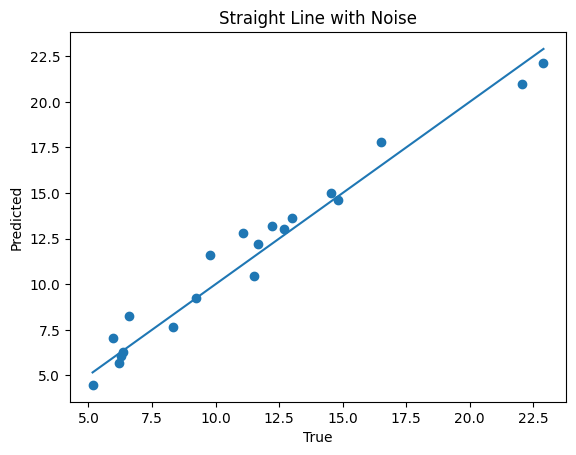

In [12]:
# Generate synthetic data
np.random.seed(0)
X = np.linspace(0, 10, 100).reshape(-1, 1)
epsilon = np.random.normal(0, 1, size=(100, 1))
y = 3 + 2 * X + epsilon

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Fit model
model = LinearRegressionClosedForm()
model.fit(X_train, y_train)

print("Learned coef_:", model.weights[1])
print("Learned intercept_:", model.weights[0])


# Predictions
y_pred = model.predict(X_test)

print("MSE:", mse(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

# Plot prediction vs true
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("True")
plt.ylabel("Predicted")
plt.title("Straight Line with Noise")
plt.show()


Experiment 2, collinearity and ridge

In [13]:
# Generate collinear features
np.random.seed(1)
x1 = np.random.rand(200, 1)
x2 = x1 + 0.01 * np.random.randn(200, 1)
X = np.hstack([x1, x2])
y = 4 + 3 * x1 - 2 * x2 + 0.1 * np.random.randn(200, 1)

alphas = [0, 1e-3, 1e-2, 1e-1, 1]
results = []

for alpha in alphas:
    model = LinearRegressionClosedForm()  
    X_train, X_test, y_train, y_test = train_test_split(X, y)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    coef_norm = np.linalg.norm(model.weights[1:])  

    results.append((alpha, mse(y_test, y_pred), coef_norm))

results




[(0, np.float64(0.011054222735760667), np.float64(3.512170299507179)),
 (0.001, np.float64(0.012339626569262751), np.float64(3.5224487371731947)),
 (0.01, np.float64(0.011136372800074488), np.float64(3.5696302756025298)),
 (0.1, np.float64(0.010263672634206387), np.float64(3.5108274563203983)),
 (1, np.float64(0.011157984903690474), np.float64(3.2939203976658247))]

As alpha increases, Ridge regularization penalizes large coefficient values. Because x1 and x2 are highly collinear, the unregularized model becomes unstable and assigns large opposite-sign weights to the two features. When alpha increases, the weight vector norm decreases and the model becomes more stable. This reduces overfitting and improves generalization.

Experiment 3, polynomial regression

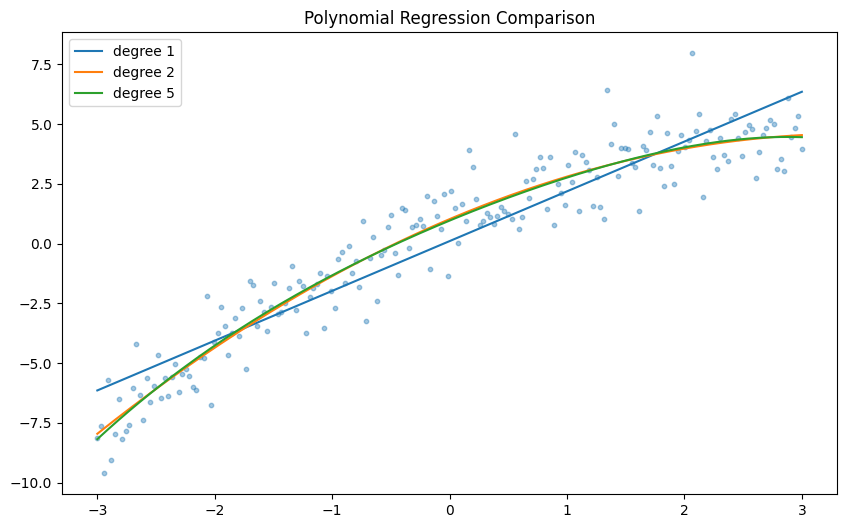

In [14]:
np.random.seed(2)
X = np.linspace(-3, 3, 200).reshape(-1, 1)
epsilon = np.random.normal(0, 1, size=(200, 1))
y = 1 + 2 * X - 0.3 * X**2 + epsilon

def poly_features(x, degree):
    return np.hstack([x**i for i in range(1, degree+1)])

degrees = [1, 2, 5]

plt.figure(figsize=(10, 6))

for deg in degrees:
    X_poly = poly_features(X, deg)
    model = LinearRegressionClosedForm()
    model.fit(X_poly, y)
    
    y_pred = model.predict(X_poly)
    
    plt.plot(X, y_pred, label=f"degree {deg}")

plt.scatter(X, y, s=10, alpha=0.4)
plt.title("Polynomial Regression Comparison")
plt.legend()
plt.show()


Degree 1 (linear) cannot capture the curvature of the data and underfits.
Degree 2 matches the ground truth because the true function is quadratic.
Degree 5 fits the data but produces unnecessary oscillations, which may overfit.
Therefore, degree 2 provides the best balance of bias and variance.